# Alignment Visualizations

### Imports

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 1

from alignment_evaluation import *
import shutil

# import matplotlib
# matplotlib.use("pgf")
# matplotlib.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     'font.family': 'serif',
#     'text.usetex': True,
#     'pgf.rcfonts': False,
# })

import seaborn as sns
sns.set(rc={'figure.figsize':(11,4)})
import pandas as pd
import re
import json
from ipywidgets import interactive, interact, fixed, interact_manual, SelectMultiple
from ipywidgets import *
from IPython.display import display

import ipywidgets as widgets

## Parameters

In [2]:
num_populations = 8

feature_extractors = ["mc_fingerfocus","mc_dilation"]
score_functions = ["hamming_distance", "hamming_dist_subsampled"]
alignment_methods = ["id", "leftmost_edge", "huang_normalization", "huang_fingertip", "huang_leftmost", "miura_matching", "center_of_mass"]
sides_model = ["left", "right"]
sides_probe = ["left", "right", "as_model"]
fingers_model = ["thumb", "index", "middle", "little", "ring"]
fingers_probe = ["thumb", "index", "middle", "little", "ring", "as_model"]
camera_model = [1, 2]
camera_probe = [1, 2, "as_model"]



## Single Tab Widget

In [3]:
class Selector(widgets.GridBox):
    
    idx = {
        "color_picker": 0,
        "title": 1,
        "feature_extractor": 2,
        "alignment": 3,
        "id_m": 4,
        "id_p": 5,
        "side_m": 6,
        "side_p": 7,
        "finger_m": 8,
        "finger_p": 9,
        "trial_m": 10,
        "trial_p": 11,
        "camera_m": 12,
        "camera_p": 13
    }
    
    def __init__(self):
        
        color_picker = widgets.ColorPicker(
            concise=True,
            description='Color:',
            value='#efefef',
        )
        
        title = widgets.Text(
            value='',
            placeholder='Describe your distribution',
            description='Title :',
            disabled=False
        )
        
        feature_extractor = widgets.Select(
            options=feature_extractors,
            value=feature_extractors[0],
            # rows=10,
            description='Feat. Extr:',
            disabled=False
        )
        
        alignment_method = widgets.Select(
            options=alignment_methods,
            value=alignment_methods[0],
            # rows=10,
            description='Align. Mtd:',
            disabled=False
        )

        sides_m = widgets.SelectMultiple(
            options=sides_model,
            value=sides_model,
            # rows=10,
            description='Sides M:',
            disabled=False
        )
    
        sides_p = widgets.SelectMultiple(
            options=sides_probe,
            value=sides_probe[-1:],
            # rows=10,
            description='Sides P:',
            disabled=False
        )
        
        fingers_m = widgets.SelectMultiple(
            options=fingers_model,
            value=fingers_model,
            # rows=10,
            description='Fingers M:',
            disabled=False
        )
        fingers_p = widgets.SelectMultiple(
            options=fingers_probe,
            value=fingers_probe[-1:],
            # rows=10,
            description='Fingers P:',
            disabled=False
        )
        
        ids_m = widgets.Text(
            value='',
            placeholder='all | 1,2,3,...',
            description='IDs M :',
            disabled=False
        )
        ids_p = widgets.Text(
            value='',
            placeholder='all | all_comb | as_model | 1,2..',
            description='IDs P:',
            disabled=False,
            layout={'width': "300px"}

        )
        
        trial_m = widgets.Text(
            value='',
            placeholder='all | 1,2,3,...',
            description='Trials M :',
            disabled=False
        )
        trial_p = widgets.Text(
            value='',
            placeholder='all | all_comb | as_model | 1,2..',
            description='Trials P:',
            disabled=False
        )
        
        camera_m = widgets.SelectMultiple(
            options=camera_model,
            value=camera_model,
            # rows=10,
            description='Cameras M:',
            disabled=False
        )
        camera_p = widgets.SelectMultiple(
            options=camera_probe,
            value=camera_probe[-1:],
            # rows=10,
            description='Cameras P:',
            disabled=False
        )


        items = [color_picker, title, feature_extractor, alignment_method, ids_m, ids_p, sides_m, sides_p, fingers_m, fingers_p, trial_m, trial_p, camera_m, camera_p]
        
        super().__init__(items, layout=widgets.Layout(grid_template_columns="repeat(2, 450px)"))

## Tab Layout

In [4]:
population_grids = [Selector() for i in range(0,num_populations)]

In [5]:
tab = widgets.Tab()
tab.children = population_grids
[tab.set_title(i, "Population " + str(i + 1)) for i in range(len(population_grids))]

[None, None, None, None, None, None, None, None]

## Experiment Settings

In [6]:
experiment_id = widgets.Text(
    value='1',
    placeholder='enter number >= 1',
    description='Exp. ID:',
    disabled=False
)

dataset_id = widgets.Text(
    value='',
    placeholder='enter number >= 1',
    description='Data ID:',
    disabled=False
)

score_function = widgets.Select(
    options=score_functions,
    value=score_functions[0],
    # rows=10,
    description='Score Func:',
    disabled=False
)
items = [experiment_id, dataset_id, score_function, tab]
experiment_settings = widgets.GridBox(items, layout=widgets.Layout(grid_template_columns="repeat(1, 1000px)"))

## Extract JSON from interactive

In [7]:
comb_params = [] # parameters for which all unique combinations will be chosen (instead of cross product)

In [8]:
def get_value(tab_id, field):
    return population_grids[tab_id].children[Selector.idx[field]].value

In [9]:
def replace_text_by_list(txt : str, field):
    if txt == "all":
        return []
    elif txt == "all_comb" and not "_m" in field:
        comb_params.append(Selector.idx[field] - 1)
    elif txt == "as_model" and not "_m" in field:
        return [None]
    else: # try to parse as list of integers
        txt = txt.replace(" ", "")
        numbers = txt.split(",")
        return list(map(lambda x: int(x), numbers))

In [10]:
def filter_same_as_model(ll, field):
    for l in ll:
        if l == "as_model":
            return [None]
    return ll

In [11]:
def extract_json(tab_id):
    comb_params.clear()
    data = {
        "spec" : {
            "dataset_id": num_to_roman(int(dataset_id.value)),
            "score_function": [score_function.value],
            "feature_extractor": [get_value(tab_id, "feature_extractor")],
            "alignment": [get_value(tab_id, "alignment")],
            "id_m": replace_text_by_list(get_value(tab_id, "id_m"), "id_m"),
            "id_p": replace_text_by_list(get_value(tab_id, "id_p"), "id_p"),
            "side_m": get_value(tab_id, "side_m"),
            "side_p": filter_same_as_model(get_value(tab_id, "side_p"), "side_p"),
            "finger_m": get_value(tab_id, "finger_m"),
            "finger_p": filter_same_as_model(get_value(tab_id, "finger_p"), "finger_p"),
            "trial_m": replace_text_by_list(get_value(tab_id, "trial_m"), "trial_m"),
            "trial_p": replace_text_by_list(get_value(tab_id, "trial_p"), "trial_p"),
            "camera_m": get_value(tab_id, "camera_m"),
            "camera_p": filter_same_as_model(get_value(tab_id, "camera_p"), "camera_p"),
        },
        "idx" : {
            "dataset_id": 0,
            "score_function": 1,
            "feature_extractor": 2,
            "alignment": 3,
            "id_m": 4,
            "id_p": 5,
            "side_m": 6,
            "side_p": 7,
            "finger_m": 8,
            "finger_p": 9,
            "trial_m": 10,
            "trial_p": 11,
            "camera_m": 12,
            "camera_p": 13
        }
    }
    if len(comb_params) == 1:
        data["combination_param_pos"] = comb_params[0]
    else:
        data["combination_param_pos"] = None
    
    return json.dumps(data) # returns json string
    

## Compute Dataset Button

In [12]:
button = widgets.Button(description="Generate Specification")
output = widgets.Output()

@output.capture(clear_output=True)
def on_button_clicked(b):
    with output:
        exp_id = num_to_roman(int(experiment_id.value))
        experiment_path = "experiments/experiment_" + exp_id
                
        # remove path if already existing:
        if os.path.isdir(experiment_path):
            shutil.rmtree(experiment_path)
        os.system("mkdir " + experiment_path)
        
        # write experiment metadata
        f = open(experiment_path + "/metadata.txt", "w")
        f.write(str(num_populations) + "\n") # Number of populations
        for i in range(num_populations):
            f.write(get_value(i, "color_picker") + "\n")
            f.write(get_value(i, "title") + "\n")
        f.close()
    
        for i in range(num_populations):
            print("Loading population " + str(i + 1) + "...")
            population_id = num_to_roman(i + 1)
            pop_path = experiment_path + "/population_" + population_id
            os.system("mkdir " + pop_path)
            
            pop_jsons = extract_json(i)
            with open(pop_path + '/spec.json', 'w') as outfile:
                json.dump(pop_jsons, outfile)
            
            #run_population_experiment(exp_id, population_id)
        print("Finished")
button.on_click(on_button_clicked)

## Load Dataset from Previous Settings (TODO)

In [13]:
def load_exp_settings(exp_nr):
    pass

In [14]:
experiment_setting_nr = None



# Dataset Loader

In [15]:
display(experiment_settings)
display(button, output)

GridBox(children=(Text(value='1', description='Exp. ID:', placeholder='enter number >= 1'), Text(value='', des…

Button(description='Generate Specification', style=ButtonStyle())

Output()

# Run Experiment

In [24]:
run_experiment = True
experiment_id

Text(value='1', description='Exp. ID:', placeholder='enter number >= 1')

In [28]:
if run_experiment:
    exp_id = num_to_roman(int(experiment_id.value))
    experiment_path = "experiments/experiment_" + exp_id
    path = experiment_path + "/metadata.txt"

    f = open(path, "r")
    lines = f.read().splitlines()
    f.close()

    num_populations = int(lines.pop(0))

    for i in range(num_populations):
        print("Loading population " + str(i + 1) + "...")
        population_id = num_to_roman(i+1)
        run_population_experiment()
        pop_path = experiment_path + "/population_" + population_id
        run_population_experiment(exp_id, population_id)
    print("FINISHED")

Loading population 1...
Loading population 2...
Loading population 3...
Loading population 4...
Loading population 5...
Loading population 6...
miurascore: 0.19699140401146123 26 95
shifted
miurascore: 0.19125420470927434 29 83
shifted
miurascore: 0.20492957746478865 29 92
shifted
miurascore: 0.18567251461988296 28 88
shifted
miurascore: 0.14609323703217333 27 92
shifted
miurascore: 0.193456614509246 33 89
shifted
miurascore: 0.2239601848560255 28 92
shifted
miurascore: 0.20371251784864347 31 87
shifted
miurascore: 0.27590048273301143 33 87
shifted
miurascore: 0.28230371646566566 29 93
shifted
miurascore: 0.20731286650569158 31 87
shifted
miurascore: 0.27773783848550193 33 94
shifted
miurascore: 0.2800891530460623 31 88
shifted
miurascore: 0.31060969755160817 31 93
shifted
miurascore: 0.18831822759315198 30 88
shifted
miurascore: 0.2780697563306258 34 90
shifted
miurascore: 0.2835552356962935 29 91
shifted
miurascore: 0.3124101581217057 33 90
shifted
miurascore: 0.20903010033444808 29 

miurascore: 0.07888861324733316 6 173
shifted
miurascore: 0.08677438659485337 34 101
shifted
miurascore: 0.0803336259877085 26 123
shifted
miurascore: 0.10190185489551537 52 96
shifted
miurascore: 0.1663346613545816 20 88
shifted
miurascore: 0.09818543375590352 52 82
shifted
miurascore: 0.0953807740324594 32 114
shifted
miurascore: 0.1446260525012382 38 92
shifted
miurascore: 0.19767147557580353 24 87
shifted
miurascore: 0.1994308750296419 35 91
shifted
miurascore: 0.24881928908774545 29 88
shifted
miurascore: 0.09304677623261691 33 129
shifted
miurascore: 0.08810679611650483 0 92
shifted
miurascore: 0.11575148234080951 9 86
shifted
miurascore: 0.16862170087976533 34 90
shifted
miurascore: 0.11874386653581942 5 88
shifted
miurascore: 0.2036947010209042 38 89
shifted
miurascore: 0.10379550735863671 10 102
shifted
miurascore: 0.10278053624627609 20 69
shifted
miurascore: 0.09832429768358797 12 104
shifted
miurascore: 0.09006873666745671 25 65
shifted
miurascore: 0.14090674909840287 25 92

miurascore: 0.16963967178023545 25 91
shifted
miurascore: 0.1962382445141065 35 90
shifted
miurascore: 0.14977497749774976 31 90
shifted
miurascore: 0.19809874271695793 29 91
shifted
miurascore: 0.17412574741801046 20 92
shifted
miurascore: 0.19464285714285706 37 90
shifted
miurascore: 0.1622980251346499 27 92
shifted
miurascore: 0.20210787352758827 30 91
shifted
miurascore: 0.1268629589240276 32 96
shifted
miurascore: 0.18341937443061035 23 90
shifted
miurascore: 0.2263245338748384 35 90
shifted
miurascore: 0.27708132433301186 22 90
shifted
miurascore: 0.1681580909768829 43 91
shifted
miurascore: 0.2175416535680603 14 90
shifted
miurascore: 0.2187326805837797 36 91
shifted
miurascore: 0.27069645203679366 22 90
shifted
miurascore: 0.1941573033707865 27 85
shifted
miurascore: 0.22340942204953856 42 90
shifted
miurascore: 0.22161212387436852 20 91
shifted
miurascore: 0.19227029654837136 40 88
shifted
miurascore: 0.21058879392212723 38 88
shifted
miurascore: 0.2042440318302387 22 93
shift

shifted
miurascore: 0.31150159744408934 29 92
shifted
miurascore: 0.20991926182237594 38 85
shifted
miurascore: 0.19163763066202083 26 93
shifted
miurascore: 0.2541143654114365 37 93
shifted
miurascore: 0.2857142857142857 28 86
shifted
miurascore: 0.327596098680436 29 88
shifted
miurascore: 0.348915368163764 29 92
shifted
miurascore: 0.23964326812428074 32 84
shifted
miurascore: 0.2118181818181818 26 93
shifted
miurascore: 0.273335190860964 32 92
shifted
miurascore: 0.3098168718102671 29 87
shifted
miurascore: 0.2463054187192118 33 87
shifted
miurascore: 0.23040899157040268 28 91
shifted
miurascore: 0.28459383753501394 32 95
shifted
miurascore: 0.3161810291382516 30 85
shifted
miurascore: 0.27975357042845134 29 98
shifted
miurascore: 0.25323076923076915 31 84
shifted
miurascore: 0.136527563111798 25 89
shifted
miurascore: 0.14401772525849332 40 95
shifted
miurascore: 0.1791734638390429 31 88
shifted
miurascore: 0.18044545111362775 41 96
shifted
miurascore: 0.21728786677240278 28 93
shi

shifted
miurascore: 0.14783653846153844 16 77
shifted
miurascore: 0.26103404791929374 35 87
shifted
miurascore: 0.21879775853285788 28 93
shifted
miurascore: 0.23275686673448617 35 89
shifted
miurascore: 0.21247113163972284 25 90
shifted
miurascore: 0.21619911411094697 30 101
shifted
miurascore: 0.1853842020419129 22 78
shifted
miurascore: 0.2783898305084745 30 92
shifted
miurascore: 0.24169500392362017 28 87
shifted
miurascore: 0.2195228715254979 25 105
shifted
miurascore: 0.17898193760262723 25 74
shifted
miurascore: 0.2514407684098185 25 102
shifted
miurascore: 0.21434437448672317 28 78
shifted
miurascore: 0.23525848142164774 29 90
shifted
miurascore: 0.2517857142857142 30 92
shifted
miurascore: 0.21174590491410303 34 91
shifted
miurascore: 0.20206341217916451 27 92
shifted
miurascore: 0.14781058054289672 45 91
shifted
miurascore: 0.1324134592108448 17 98
shifted
miurascore: 0.15529363110008268 38 92
shifted
miurascore: 0.1671786994367639 21 91
shifted
miurascore: 0.3011660635303577

...

Translated img center  120.0 188.0
CoM translated img:  (120.06388206388206, 187.69638469638468)
CoM original img:  (131.6563138536984, 165.02656313853697)
Original img center:  120.0 188.0
To translate by:  -11.656313853698407 22.97343686146303 -12 23
Translated img center  120.0 188.0
CoM translated img:  (119.6563138536984, 188.02656313853697)
CoM original img:  (122.9421458625526, 203.8990182328191)
Original img center:  120.0 188.0
To translate by:  -2.942145862552593 -15.899018232819088 -3 -16
Translated img center  120.0 188.0
CoM translated img:  (119.9421458625526, 187.8990182328191)
CoM original img:  (127.38449416955562, 217.84494169555626)
Original img center:  120.0 188.0
To translate by:  -7.384494169555623 -29.84494169555626 -7 -30
Translated img center  120.0 188.0
CoM translated img:  (120.38449416955562, 187.84494169555626)
CoM original img:  (120.43361128928801, 212.16709429121232)
Original img center:  120.0 188.0
To translate by:  -0.4336112892880095 -24.1670942912

CoM original img:  (136.84913468773513, 178.16139954853273)
Original img center:  120.0 188.0
To translate by:  -16.84913468773513 9.838600451467272 -17 10
Translated img center  120.0 188.0
CoM translated img:  (119.84913468773514, 188.16139954853273)
CoM original img:  (139.80699588477367, 185.36543209876544)
Original img center:  120.0 188.0
To translate by:  -19.80699588477367 2.6345679012345613 -20 3
Translated img center  120.0 188.0
CoM translated img:  (119.80699588477366, 188.36543209876544)
CoM original img:  (121.44089673913044, 228.86616847826087)
Original img center:  120.0 188.0
To translate by:  -1.4408967391304373 -40.866168478260875 -1 -41
Translated img center  120.0 188.0
CoM translated img:  (120.44089673913044, 187.86616847826087)
CoM original img:  (118.61538461538461, 225.445)
Original img center:  120.0 188.0
To translate by:  1.3846153846153868 -37.44499999999999 1 -37
Translated img center  120.0 188.0
CoM translated img:  (119.61538461538461, 188.445)
CoM ori

To translate by:  9.841249601530123 -34.25884603124004 10 -34
Translated img center  120.0 188.0
CoM translated img:  (120.15875039846988, 188.25884603124004)
CoM original img:  (124.97870855148342, 173.70366492146596)
Original img center:  120.0 188.0
To translate by:  -4.978708551483422 14.296335078534042 -5 14
Translated img center  120.0 188.0
CoM translated img:  (119.97870855148342, 187.70366492146596)
CoM original img:  (121.4667363288053, 174.03483106931384)
Original img center:  120.0 188.0
To translate by:  -1.4667363288052968 13.965168930686161 -1 14
Translated img center  120.0 188.0
CoM translated img:  (120.4667363288053, 188.03483106931384)
CoM original img:  (113.7670906200318, 220.44515103338634)
Original img center:  120.0 188.0
To translate by:  6.232909379968206 -32.44515103338634 6 -32
Translated img center  120.0 188.0
CoM translated img:  (119.7670906200318, 188.44515103338634)
CoM original img:  (112.66312516195906, 217.81135009069706)
Original img center:  120.

CoM original img:  (117.50231410058623, 187.82690527614935)
Original img center:  120.0 188.0
To translate by:  2.497685899413767 0.17309472385065305 2 0
Translated img center  120.0 188.0
CoM translated img:  (119.50231410058623, 187.82690527614935)
CoM original img:  (122.44213444213445, 181.06063756063756)
Original img center:  120.0 188.0
To translate by:  -2.4421344421344457 6.939362439362441 -2 7
Translated img center  120.0 188.0
CoM translated img:  (120.44213444213445, 188.06063756063756)
CoM original img:  (128.10692254969157, 219.39856065798492)
Original img center:  120.0 188.0
To translate by:  -8.106922549691575 -31.398560657984916 -8 -31
Translated img center  120.0 188.0
CoM translated img:  (120.10692254969157, 188.39856065798492)
CoM original img:  (124.0499095840868, 212.68209764918626)
Original img center:  120.0 188.0
To translate by:  -4.049909584086805 -24.68209764918626 -4 -25
Translated img center  120.0 188.0
CoM translated img:  (120.0499095840868, 187.682097

FINISHED


# Visualization

In [18]:
experiment_id

Text(value='1', description='Exp. ID:', placeholder='enter number >= 1')

### Globals

In [19]:
def color_to_float(hex_color):
    hex_color = hex_color[1:7]
    r = hex_color[:2]
    g = hex_color[2:4]
    b = hex_color[4:6]
    
    c = [int(r, 16) / 255, int(g, 16) / 255, int(b, 16) / 255]
    return c

In [20]:
def read_metadata(path):
    colors = []
    titles = []
    num_populations = 0
    
    f = open(path, "r")
    lines = f.read().splitlines()
    f.close()
    
    num_populations = int(lines.pop(0))
    for i in range(num_populations):
        color_line = lines.pop(0)
        colors.append(color_to_float(color_line))
        titles.append(lines.pop(0))
        

    return num_populations, colors, titles

## Run this cell to visualize

experiments/experiment_vi
0.9997360702717345
0.9999208523398893


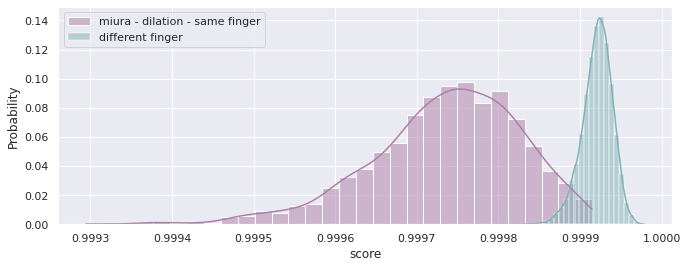

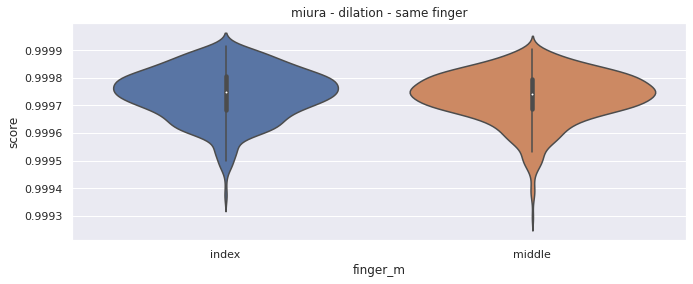

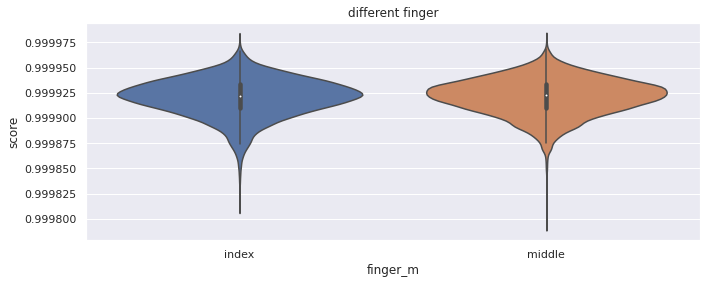

In [108]:
sns.set(style="darkgrid")

exp_id = num_to_roman(int(experiment_id.value))
experiment_path = "experiments/experiment_" + exp_id
print(experiment_path)
num_pop, colors, titles = read_metadata(experiment_path + "/metadata.txt")

colors[7] = [0.5, 0.7, 0.7]

select = [False, False, False, False, False, True, False, True]


for i in range(num_pop):
    if select[i]:
        pop_id = num_to_roman(i + 1)
        df = pd.read_csv(experiment_path + "/population_" + pop_id + "/results.csv")
        #df = df[df["finger_m"] == "middle"]
        print(df["score"].mean())

        sns.histplot(data=df, x="score", stat="probability", color=colors[i], label=titles[i], kde=True, fill=True, common_norm=False, common_bins=False, cumulative=False, bins=30) #, ax=axs[2])
plt.legend()
plt.show()

for i in range(num_pop):
    if select[i]:
        pop_id = num_to_roman(i + 1)
        df = pd.read_csv(experiment_path + "/population_" + pop_id + "/results.csv")
        sns.violinplot(x=df["finger_m"], y=df["score"])
        plt.title(titles[i])
        plt.show()